In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib

In [3]:
import sys
sys.path.append('../data_preprocessing')

In [4]:
import feature_engineering_scaling as fes

In [5]:
# One-hot encode the target variable
y_cat = to_categorical(fes.y)

In [6]:
X = fes.X_scaled

In [7]:
scaler = MinMaxScaler()
X.loc[:, 'time'] = scaler.fit_transform(X[['time']])  # Normalize safely

In [8]:
# Save scaler for inverse transformation later
joblib.dump(scaler, '../scalers/time_scaler.pkl')

['../scalers/time_scaler.pkl']

In [9]:
X.head()

,energy,r,z,phi,time
0,0.000350,0.001903,0.002125,0.982794,0.000000
1,0.277952,0.702870,0.820725,-2.270700,0.001030
2,0.017027,0.769946,-0.602846,2.305639,0.001030
3,0.117614,0.849347,0.578648,1.856658,0.001031
4,0.723605,0.180800,0.423572,3.138980,0.001031


In [10]:
# Further split using train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=0)

In [11]:
# Further split using train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

# Simple ANN

In [12]:
#Simple MLP
def simple_model_ann (input_shape, output_shape):
    model= keras.Sequential(
        [
            keras.Input(shape=input_shape),
            layers.Flatten(),
            layers.Dense (256, activation = "relu"),
            layers.Dense (256, activation = "relu"),
            layers.Dense (output_shape, activation = "softmax"),
        
        ]
    )
    model.compile (loss="categorical_crossentropy", optimizer = "adam", metrics=['accuracy'])
    
    return model

In [13]:
#For the first radioactive chain i.e. BiPo 214
model = simple_model_ann(X_train.shape[1], y_train.shape[1])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 5)                 0         
                                                                 
 dense (Dense)               (None, 256)               1536      
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dense_2 (Dense)             (None, 10)                2570      
                                                                 
Total params: 69898 (273.04 KB)
Trainable params: 69898 (273.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2025-03-10 14:48:23.414702: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [14]:
#Callback to decrease the learning rate and to stop early in case the loss hits a plateau
callbacks=[
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1, min_lr=1E-6),
     keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
]

In [15]:
# Train the first model
history = model.fit(X_train, y_train, epochs=200, batch_size=10000, verbose=2,
                      validation_data=(X_val, y_val),
                      callbacks=callbacks)

Epoch 1/200
413/413 - 56s - loss: 1.2670 - accuracy: 0.5212 - val_loss: 1.0895 - val_accuracy: 0.6061 - lr: 0.0010 - 56s/epoch - 136ms/step
Epoch 2/200
413/413 - 47s - loss: 0.9493 - accuracy: 0.6624 - val_loss: 0.8156 - val_accuracy: 0.6940 - lr: 0.0010 - 47s/epoch - 115ms/step
Epoch 3/200
413/413 - 47s - loss: 0.7664 - accuracy: 0.7010 - val_loss: 0.7458 - val_accuracy: 0.7032 - lr: 0.0010 - 47s/epoch - 113ms/step
Epoch 4/200
413/413 - 60s - loss: 0.7330 - accuracy: 0.7071 - val_loss: 0.7279 - val_accuracy: 0.7081 - lr: 0.0010 - 60s/epoch - 146ms/step
Epoch 5/200
413/413 - 68s - loss: 0.7257 - accuracy: 0.7087 - val_loss: 0.7289 - val_accuracy: 0.7070 - lr: 0.0010 - 68s/epoch - 165ms/step
Epoch 6/200
413/413 - 86s - loss: 0.7225 - accuracy: 0.7095 - val_loss: 0.7229 - val_accuracy: 0.7099 - lr: 0.0010 - 86s/epoch - 208ms/step
Epoch 7/200
413/413 - 65s - loss: 0.7214 - accuracy: 0.7098 - val_loss: 0.7199 - val_accuracy: 0.7115 - lr: 0.0010 - 65s/epoch - 158ms/step
Epoch 8/200
413/413 

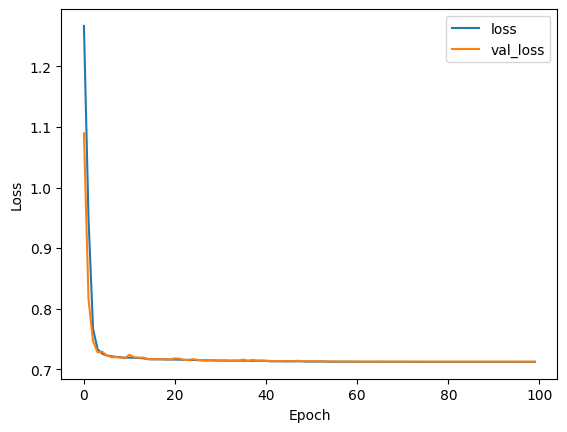

In [16]:
#Plot the loss over the number of epochs
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

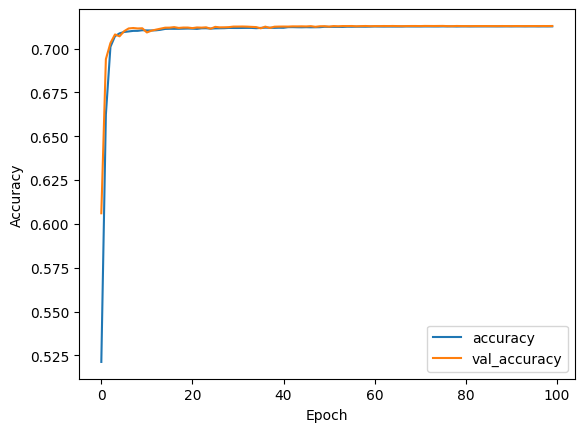

In [17]:
#Plot the accuracy over the number of epochs
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [18]:
model.save('../models/model_ann_whole.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
